# Begin

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp
import sqlite3

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np
import einops
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import DataLoader

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from dataset_utils import *
from models import *
from utils import * # @launchit.collect
from logging_utils import *
from image_utils import *
from model_registry import *
from torch_helpers import *
import launchit # @launchit.disable
from hp_utils import *

# Init

In [3]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    model_group_uri=None,
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

MODEL_REGISTRY = ModelRegistry(CONFIG.model_group_uri, download_nexus_url='http://nexus-slave:8081')

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15f_explore_noncausal_01.ipynb',
 'self_name': '15f_explore_noncausal_01',
 'subproject_name': '15_transformer',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [4]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    # dataset params
    db_fname: str = None
    # model params
    model_artifact_source: str = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

# Dataset

## Configure

In [5]:
# @launchit.disable
# @launchit.collect
HP.db_fname = 'dataset_5_128.db'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'db_fname': 'dataset_5_128.db',
 'model_artifact_source': None}


## get_db_con

In [6]:
def get_db_con(hp=None):
    hp = LangUtils.coalesce(hp, HP)
    assert hp.db_fname, f'Uninitialized {hp.db_fname=}'
    return sqlite3.connect(f'file:{os.path.join(CONFIG.private_data_path, hp.db_fname)}?mode=ro', uri=True)

## DataComponents

In [7]:
@dataclass
class DataComponents:
    meta: object = None
    images: dict = None
    test_images: dict = None
    image_labels: dict = None
    test_image_labels: dict = None
    vocab_token_ind_to_vocab_token: dict = None
    pos_token_ind_to_pos_token: dict = None
    pos_token_inds: object = None

    def get_image(self, image_ind, is_test):
        data = (self.images, self.test_images)[is_test][image_ind]
        return np.load(BytesIO(data))

    def get_image_label(self, image_ind, is_test):
        return (self.image_labels, self.test_image_labels)[is_test][image_ind]

DC = DataComponents()

## Load

In [8]:
with get_db_con() as db_con:
    DC.meta = load_meta(db_con)
    image_and_labels = db_con.execute('SELECT image_ind, data, label FROM images').fetchall()
    DC.images = dict(map(lambda i: (i[0], i[1]), image_and_labels))
    DC.image_labels = dict(map(lambda i: (i[0], i[2]), image_and_labels))
    image_and_labels = db_con.execute('SELECT image_ind, data, label FROM test_images').fetchall()
    DC.test_images = dict(map(lambda i: (i[0], i[1]), image_and_labels))
    DC.test_image_labels = dict(map(lambda i: (i[0], i[2]), image_and_labels))
    DC.vocab_token_ind_to_vocab_token = {}

    for vt in (load_vocab_tokens(db_con).itertuples()):
        if vt.data is not None:
            vt = vt._replace(data=np.load(BytesIO(vt.data)))

        DC.vocab_token_ind_to_vocab_token[vt.Index] = vt

    DC.pos_token_ind_to_pos_token = dict(map(lambda t: (t.Index, t), load_pos_tokens(db_con).itertuples()))
    
    for table_name in ('noncausal_samples', 'test_noncausal_samples'):
        rows = db_con.execute(f'SELECT pos_token_inds, COUNT(*) FROM {table_name} GROUP BY pos_token_inds').fetchall()
        assert len(rows) == 1
        pos_token_inds = np.array(list(map(int, rows[0][0].split(','))))

        # Make sure all samples (both train and test) have the same positional tokens
        if DC.pos_token_inds is None:
            if DC.pos_token_inds is None:
                DC.pos_token_inds = pos_token_inds
            else:
                assert np.all(DC.pos_token_inds == pos_token_inds)

# TRAIN_MODEL

## Configure

In [9]:
# @launchit.disable
# @launchit.collect
HP.model_artifact_source = '15f_combo_noncausal_01:1'
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'db_fname': 'dataset_5_128.db',
 'model_artifact_source': '15f_combo_noncausal_01:1'}


## Create

In [13]:
ntp

NoncausalTransformer.Params(vocab_size=131, pos_tokens_count=576, embedding_size=384, heads_count=16, layers_count=6)

In [12]:
asp = hp_parse_artifact_source(HP.model_artifact_source)
tp = MODEL_REGISTRY.get_asset_content(asp.model_name, asp.model_version, 'json', 'transformer_params')
tp = json.loads(tp.decode())
ntp = NoncausalTransformer.Params(**tp)
LOG(f'Transformer params={dataclasses.asdict(ntp)}')
assert False
transformer = NoncausalTransformer(ntp)
pt = mr.get_asset_content(asp.model_name, asp.model_version, 'pt', 'transformer')
transformer.load_state_dict(torch.load(BytesIO(pt)))
transformer.requires_grad_(not HP.freeze_transformer)
model = ComboModel(ntp.vocab_size, npt.pos_tokens_count, 
    transformer, ntp.embedding_size)
model = model.to(CONFIG.cuda_device)





model = ComboModel(len(DC.vocab_token_ind_to_vocab_token), len(DC.pos_token_ind_to_pos_token), HP)
model = model.to(CONFIG.cuda_device)
data_loader = DataLoader(DC.df_samples.index, batch_size=HP.batch_size, shuffle=True)
lr_params = hp_parse_learn_rate(HP.learn_rate)
optimizer = getattr(torch.optim, HP.optimizer)(model.parameters(), lr=lr_params.learn_rate)
lr_scheduler = LrSchedulerWrapper(optimizer, lr_params)

Transformer params={'vocab_size': 131, 'pos_tokens_count': 576, 'embedding_size': 384, 'heads_count': 16, 'layers_count': 6}


AssertionError: 

## Train

In [45]:
# @launchit.disable_2
only_pos_token_inds = torch.tensor(DC.pos_token_inds).to(CONFIG.cuda_device)

for epoch in tqdm(range(HP.epochs_count + 1), desc='Epoch', disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('EPOCH', epoch):
        epoch_metrics = ('loss_all', 'loss_pred', 'loss_cls', 'accuracy', 'test_loss_all', 'test_loss_pred', 'test_loss_cls', 'test_accuracy')
        epoch_metrics = dict(map(lambda k: (k, RecursiveAverageFilter()), epoch_metrics))
    
        for sample_indices in tqdm(data_loader, leave=False, desc='Batch', disable=not CONFIG.is_interactive):
            optimizer.zero_grad()

            df_samples = DC.df_samples.loc[sample_indices]
            masks = generate_masks(len(df_samples.iloc[0].vocab_token_inds), HP.masking_levels)
            batch = collate_samples_to_batch(df_samples, masks, mask_value=NoncausalTransformer.MASK_TOKEN_IND, device=CONFIG.cuda_device)
            batch_shape = einops.parse_shape(batch.vocab_token_inds, 'm b s')
            pred_logits, cls_logits = model(einops.rearrange(batch.vocab_token_inds, 'm b s -> (m b) s'), only_pos_token_inds)

            # LOSS OVER PREDICTIONS
            # Turn logits and targets to just matrices where each row is a logits/probability vector
            pred_logits = einops.rearrange(pred_logits, 'mb s l -> (mb s) l')
            pred_targets = einops.rearrange(batch.targets, 'm b s l -> (m b s) l')
            # Use masks to select subset of rows which model should predict
            masks = einops.rearrange(batch.masks, 'm b s -> (m b s)')
            pred_loss = F.cross_entropy(pred_logits[masks], pred_targets[masks])

            # LOSS OVER CLASSIFICATION
            cls_targets = torch.tensor(df_samples.label.to_numpy()).to(CONFIG.cuda_device)
            cls_targets = cls_targets.expand(batch_shape['m'], -1).ravel() # aka np.tile(...)
            cls_loss = F.cross_entropy(cls_logits, cls_targets)

            # OVERALL LOSS
            loss = pred_loss + cls_loss

            if epoch > 0: # first run is a dry run to get baseline for losses and other metrics
                loss.backward()
                optimizer.step()

            for k, l in zip(('loss_all', 'loss_pred', 'loss_cls'), (loss, pred_loss, cls_loss)):
                epoch_metrics[k](l.item(), batch_size=len(df_samples))

            match_map = torch.argmax(cls_logits, axis=1) == cls_targets
            epoch_metrics['accuracy'](1, batch_size=(match_map == True).sum().item())
            epoch_metrics['accuracy'](0, batch_size=(match_map == False).sum().item())

        lr_scheduler.step(epoch_metrics['loss_all'].v)

        with eval_guard(model):
            with torch.no_grad(): 
                if epoch == 0:
                    df_test_samples = LangUtils.when(HP.test_batch_size is not None, DC.df_test_samples.sample(HP.test_batch_size), DC.df_test_samples)
                    test_masks = generate_masks(len(df_test_samples.iloc[0].vocab_token_inds), HP.masking_levels)
                    test_batch = collate_samples_to_batch(df_test_samples, test_masks, mask_value=NoncausalTransformer.MASK_TOKEN_IND, device=CONFIG.cuda_device)
                    test_batch_shape = einops.parse_shape(test_batch.vocab_token_inds, 'm b s')
                    test_vocab_token_inds = einops.rearrange(test_batch.vocab_token_inds, 'm b s -> (m b) s')
                    test_masks = einops.rearrange(test_batch.masks, 'm b s -> (m b s)')
                    test_pred_targets = einops.rearrange(test_batch.targets, 'm b s l -> (m b s) l')
                    test_cls_targets = torch.tensor(df_test_samples.label.to_numpy()).to(CONFIG.cuda_device)
                    test_cls_targets = test_cls_targets.expand(test_batch_shape['m'], -1).ravel() # aka np.tile(...)
                    
                test_pred_logits, test_cls_logits = model(test_vocab_token_inds, only_pos_token_inds)
                test_pred_logits = einops.rearrange(test_pred_logits, 'mb s l -> (mb s) l')
                test_pred_loss = F.cross_entropy(test_pred_logits[test_masks], test_pred_targets[test_masks])
                test_cls_loss = F.cross_entropy(test_cls_logits, test_cls_targets)
                test_loss = test_pred_loss + test_cls_loss
                epoch_metrics['test_loss_all'](test_loss.item())
                epoch_metrics['test_loss_pred'](test_pred_loss.item())
                epoch_metrics['test_loss_cls'](test_cls_loss.item())
                test_match_map = torch.argmax(test_cls_logits, axis=1) == test_cls_targets
                epoch_metrics['test_accuracy'](1, batch_size=(test_match_map == True).sum().item())
                epoch_metrics['test_accuracy'](0, batch_size=(test_match_map == False).sum().item())

        # Report metrics and upload figures
        concat_log = []
        
        for k, v in epoch_metrics.items():
            summary_writer.add_scalar(k, v.v, epoch)
            METRICS_SUITE[k].append(v.v)
            concat_log.append(f'{k}={v.v:.4g}')
            
        LOG(', '.join(concat_log), when=not CONFIG.is_interactive)

        if (epoch % 20) == 0 or (epoch == HP.epochs_count):
            if epoch == 0:
                df_example_samples = DC.df_test_samples.sample(3)
                example_masks = generate_masks(len(df_example_samples.iloc[0].vocab_token_inds), HP.masking_levels)

            fig = visualize_model_output(model, df_example_samples, HP.masking_levels, example_masks, is_test=True, device=CONFIG.cuda_device)
            summary_writer.add_figure(f'model_output', fig, epoch, close=False) 
            plt.close(fig) # manual closing because summar_writer may be in Mock mode leaving fig unclosed
            LOG('Figure "model_output" uploaded', when=not CONFIG.is_interactive)
        
        summary_writer.flush()

        if optuna_trial is not None:
            # https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html#optuna.trial.Trial.report:
            # > If this method is called multiple times at the same step in a trial, the reported value only the first time is stored 
            # > and the reported values from the second time are ignored.
            # In other words calling report for fold other than the first one does nothing except producing tons of warnings in console. 
            # As such only the first fold is indicative
            optuna_trial.report(epoch_metrics['loss_all'], epoch) 
    
            if optuna_trial.should_prune():
                # Despite written in docs OPTUNA_TRIAL.should_prune is not idempotent - consequent calls could lead
                # to different responses. Perhapse this is due to influence of concurrent trials running which could change
                # pruner decision. As such cache pruning result so it's immutable
                optuna_trial.set_user_attr('IS_PRUNED', True)
                LOG(f'Optuna pruning condition encountered. Stopping training')
                break        

Epoch:   0%|          | 0/2 [00:00<?, ?it/s]

Batch:   0%|          | 0/600 [00:00<?, ?it/s]

Batch:   0%|          | 0/600 [00:00<?, ?it/s]

# Train utils

## generate_masks

In [21]:
def generate_masks(l, masking_steps):
    masks = np.zeros((len(masking_steps), l), dtype=bool)
    prev_masked_count = None
    free_inds = list(range(l))
    
    for i, masked_percentage in enumerate(masking_steps):
        masked_count = int(masked_percentage * l)
        assert 0 <= masked_count <= l, masked_count
        prev_masked_count = LangUtils.coalesce(prev_masked_count, 0)
        assert prev_masked_count <= masked_count, (prev_masked_count, masked_count, masked_percentage)
        items_to_mask = masked_count - prev_masked_count
        prev_masked_count = masked_count

        if items_to_mask == 0:
            continue

        assert items_to_mask <= len(free_inds), (len(free_inds), items_to_mask, masked_percentage)

        inds_for_masking = RNG.choice(free_inds, items_to_mask, replace=False)

        if i > 0:
            masks[i][:] = masks[i-1]
            
        masks[i,inds_for_masking] = True
        free_inds = list(set(free_inds) - set(inds_for_masking))

    return masks

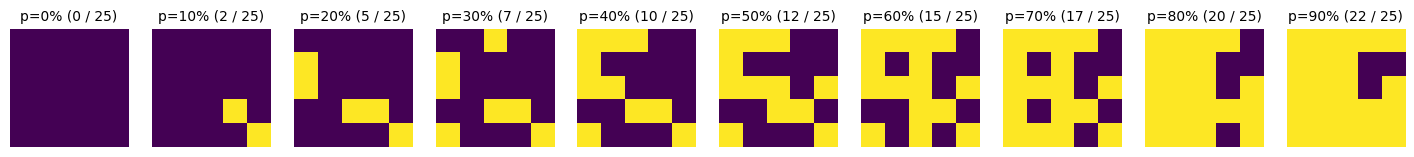

In [22]:
# @launchit.disable
masking_steps = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
masks = generate_masks(25, masking_steps)
fig, axes = plt.subplots(1, len(masks))
fig.set_figwidth(18)

for mask, ax, mp in zip(masks, axes, masking_steps):
    ax.set_title(f'p={mp*100:.0f}% ({mask.sum()} / {len(mask)})', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(mask))
    ax.set_axis_off()

## collate_samples_to_batch

In [23]:
Batch = namedtuple('Batch', 'vocab_token_inds masks targets')

def collate_samples_to_batch(df_samples, masks, mask_value, device=None):
    origin_batch = np.vstack(df_samples.vocab_token_inds)
    p = einops.rearrange(np.vstack(df_samples.p_matrix), '(b s) d -> b s d', b=len(df_samples))
    assert masks.shape[1] == origin_batch.shape[1], (masks.shape[1], origin_batch.shape[1])
    masked_batches = []

    for mask in masks:
        masked_batch = origin_batch.copy()
        masked_batch[np.arange(len(masked_batch)),np.argwhere(mask)] = mask_value
        masked_batches.append(masked_batch)

    to_tensor = lambda a: torch.tensor(a).to(device=LangUtils.coalesce(device, CONFIG.cuda_device))
    return Batch(
        vocab_token_inds=to_tensor(np.array(masked_batches)),
        masks=to_tensor(einops.rearrange(np.repeat(masks, len(df_samples), axis=0), '(m b) v -> m b v', b=len(df_samples))), 
        targets=to_tensor(np.tile(p, (len(masks),1,1,1))),
    )

## visualize_model_output

In [24]:
def visualize_model_output(model, df_samples, masking_levels, masks, is_test, device=None):
    batch = collate_samples_to_batch(df_samples, masks, mask_value=NoncausalTransformer.MASK_TOKEN_IND, device=device)
    batch_shape = einops.parse_shape(batch.vocab_token_inds, 'm b s')
    
    with eval_guard(model):
        with torch.no_grad(): 
            pred_logits, cls_logits = model(
                einops.rearrange(batch.vocab_token_inds, 'm b s -> (m b) s'), 
                torch.tensor(DC.pos_token_inds).to(device=device)
            )
            pred_logits = pred_logits.detach().cpu().numpy()
            pred_logits = einops.rearrange(pred_logits, '(m b) s l -> m b s l', b=batch_shape['b'])
            predictions = np.argmax(pred_logits, axis=-1)
            cls_logits = cls_logits.detach().cpu().numpy()
            cls_logits = einops.rearrange(cls_logits, '(m b) l -> m b l', b=batch_shape['b'])
            classes = np.argmax(cls_logits, axis=-1) 
    
    def generate_mosaic(samples_count, masking_levels_count):
        mosaic = []
        row = []
    
        for i in range(samples_count):
            row.extend([chr(ord('A') + i)] * 2)
    
        mosaic.append(row)
            
        for j in range(masking_levels_count):
            row = []
            
            for i in range(samples_count):
                prefix = chr(ord('A') + i)
                row.extend([f'{prefix}{j+1}1', f'{prefix}{j+1}2'])
            
            mosaic.append(row)
    
        return mosaic, ''.join(map(chr, ord('A') + np.arange(samples_count)))
    
    mosaic, major_letters = generate_mosaic(len(df_samples), len(masking_levels))
    fig, axd = plt.subplot_mosaic(mosaic, layout="constrained")
    fig.set_figwidth(16)
    fig.set_figheight(2 * len(mosaic))
    
    # Original image
    for sample_row, ax_name in zip(df_samples.itertuples(), major_letters):
        image = DC.get_image(sample_row.image_ind, is_test=is_test)
        axd[ax_name].set_title(f'{LangUtils.when(is_test, 'Test image', 'Image')} #{sample_row.image_ind}, {sample_row.label}')
        axd[ax_name].imshow(image)
        axd[ax_name].set_axis_off()
    
    # Masked image
    for i in range(len(batch.vocab_token_inds)):
        for j, ax_name_prefix in zip(range(len(batch.vocab_token_inds[i])), major_letters):
            assert len(batch.vocab_token_inds[i,j]) == len(DC.pos_token_inds)
            image_hat = np.zeros((DC.meta.image_size, DC.meta.image_size))
            ax = axd[f'{ax_name_prefix}{i+1}1']
            
            for vocab_token_ind, pos_token_ind in zip(batch.vocab_token_inds[i,j], DC.pos_token_inds):
                vt = DC.vocab_token_ind_to_vocab_token[vocab_token_ind.item()]
                pt = DC.pos_token_ind_to_pos_token[pos_token_ind.item()]
    
                if vocab_token_ind.item() == NoncausalTransformer.MASK_TOKEN_IND:
                    rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), DC.meta.patch_size, DC.meta.patch_size, linewidth=1, edgecolor='w', facecolor='none')
                    ax.add_patch(rect)
                else:
                    image_hat[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vt.data)
    
            ax.set_title(f'Masking level={masking_levels[i]*100:.0f}%', fontdict=dict(fontsize=10))
            ax.imshow(image_hat)
            ax.set_axis_off()
    
    # Maked image with filled in items
    for i in range(len(predictions)):
        for j, ax_name_prefix in zip(range(len(predictions[i])), major_letters):
            assert len(predictions[i,j]) == len(DC.pos_token_inds)
            assert len(predictions[i,j]) == len(batch.vocab_token_inds[i,j])
            assert len(predictions[i,j]) == len(batch.masks[i,j])
            image_hat = np.zeros((DC.meta.image_size, DC.meta.image_size))
            ax = axd[f'{ax_name_prefix}{i+1}2']
            
            for k in range(len(predictions[i,j])):
                pt = DC.pos_token_ind_to_pos_token[DC.pos_token_inds[k]]
                mask_value = batch.masks[i,j,k].item()
                
                if mask_value:
                    # masked value - get from model's output (prediction)
                    vt = DC.vocab_token_ind_to_vocab_token[predictions[i,j,k]]
                    color = LangUtils.when(batch.targets[i,j,k,vt.Index] > 0.01, 'g', 'r')
                    lw = LangUtils.when(batch.targets[i,j,k,vt.Index] > 0.01, 2, 1)
                    rect = pltpatches.Rectangle((pt.j-0.5, pt.i-0.5), DC.meta.patch_size, DC.meta.patch_size, linewidth=lw, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                else:
                    # unmasked value - get from model's input
                    vt = DC.vocab_token_ind_to_vocab_token[batch.vocab_token_inds[i,j,k].item()]
                    
    
                if vt.data is not None:
                    image_hat[pt.i:pt.i2,pt.j:pt.j2] = ArrayUtils.v2sm(vt.data)
    
            ax.set_title(f'Masking level={masking_levels[i]*100:.0f}%, label={classes[i,j]}', fontdict=dict(fontsize=10))
            ax.imshow(image_hat)
            ax.set_axis_off()

    return fig

In [25]:
# @launchit.disable
hp = Hyperparameters(embedding_size=256+128, heads_count=16, layers_count=4)
model = ComboModel(len(DC.vocab_token_ind_to_vocab_token), len(DC.pos_token_ind_to_pos_token), hp)
sample_indices = RNG.choice(DC.df_samples.index, 3, replace=False)
df_samples = DC.df_samples.loc[sample_indices]
masking_levels = [0.2, 0.4]
masks = generate_masks(len(df_samples.iloc[0].vocab_token_inds), masking_levels)
fig = visualize_model_output(model, df_samples, masking_levels, masks, is_test=False, device='cpu')

TypeError: Hyperparameters.__init__() got an unexpected keyword argument 'embedding_size'

# LaunchIt!

In [15]:
# @launchit.disable
launchit_t0 = time.time()

In [16]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{CONFIG.model_group_uri}.{CONFIG.self_name}'))
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars)
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/15_transformer/15b_encode_02-launch4.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15b_encode_02-launch4.ipynb"
